# Dielectric function demostration

In [1]:
# Prework

from pathlib import Path
from matplotlib import font_manager as fm
from vmatplot.output_settings import canvas_setting as _canvas_setting

components = [{"xx":"in-plane"},{"zz":"out-of-plane"}]
layout = "hor"
boundary = (-60, 80)

# system factors (d_c, (z_max-z_min)*d_c+2*r_be) r_be = 1.98
factor_bulk = (1, 1)                                        # for α-Beryllium and cubic Beryllium bulk
factor_a = (40, 2*1.98)                                     # for α-Beryllene monolayer
factor_b = (40, 0.0473771641975619+2*1.98)                  # for β-Beryllene monolayer


In [2]:
# font settings

import warnings
import logging

font_paths = [Path("Besley.ttf").resolve(),Path("ArbutusSlab.ttf").resolve(),]
for p in font_paths:
    fm.fontManager.addfont(str(p))

besley_name = fm.FontProperties(fname=str(font_paths[0])).get_name()
arbutus_name = fm.FontProperties(fname=str(font_paths[1])).get_name()
print("Besley:", besley_name)
print("Arbutus:", arbutus_name)

warnings.filterwarnings("ignore",message=r"Glyph \d+ .* missing from font",category=UserWarning)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)


Besley: Besley
Arbutus: Arbutus Slab


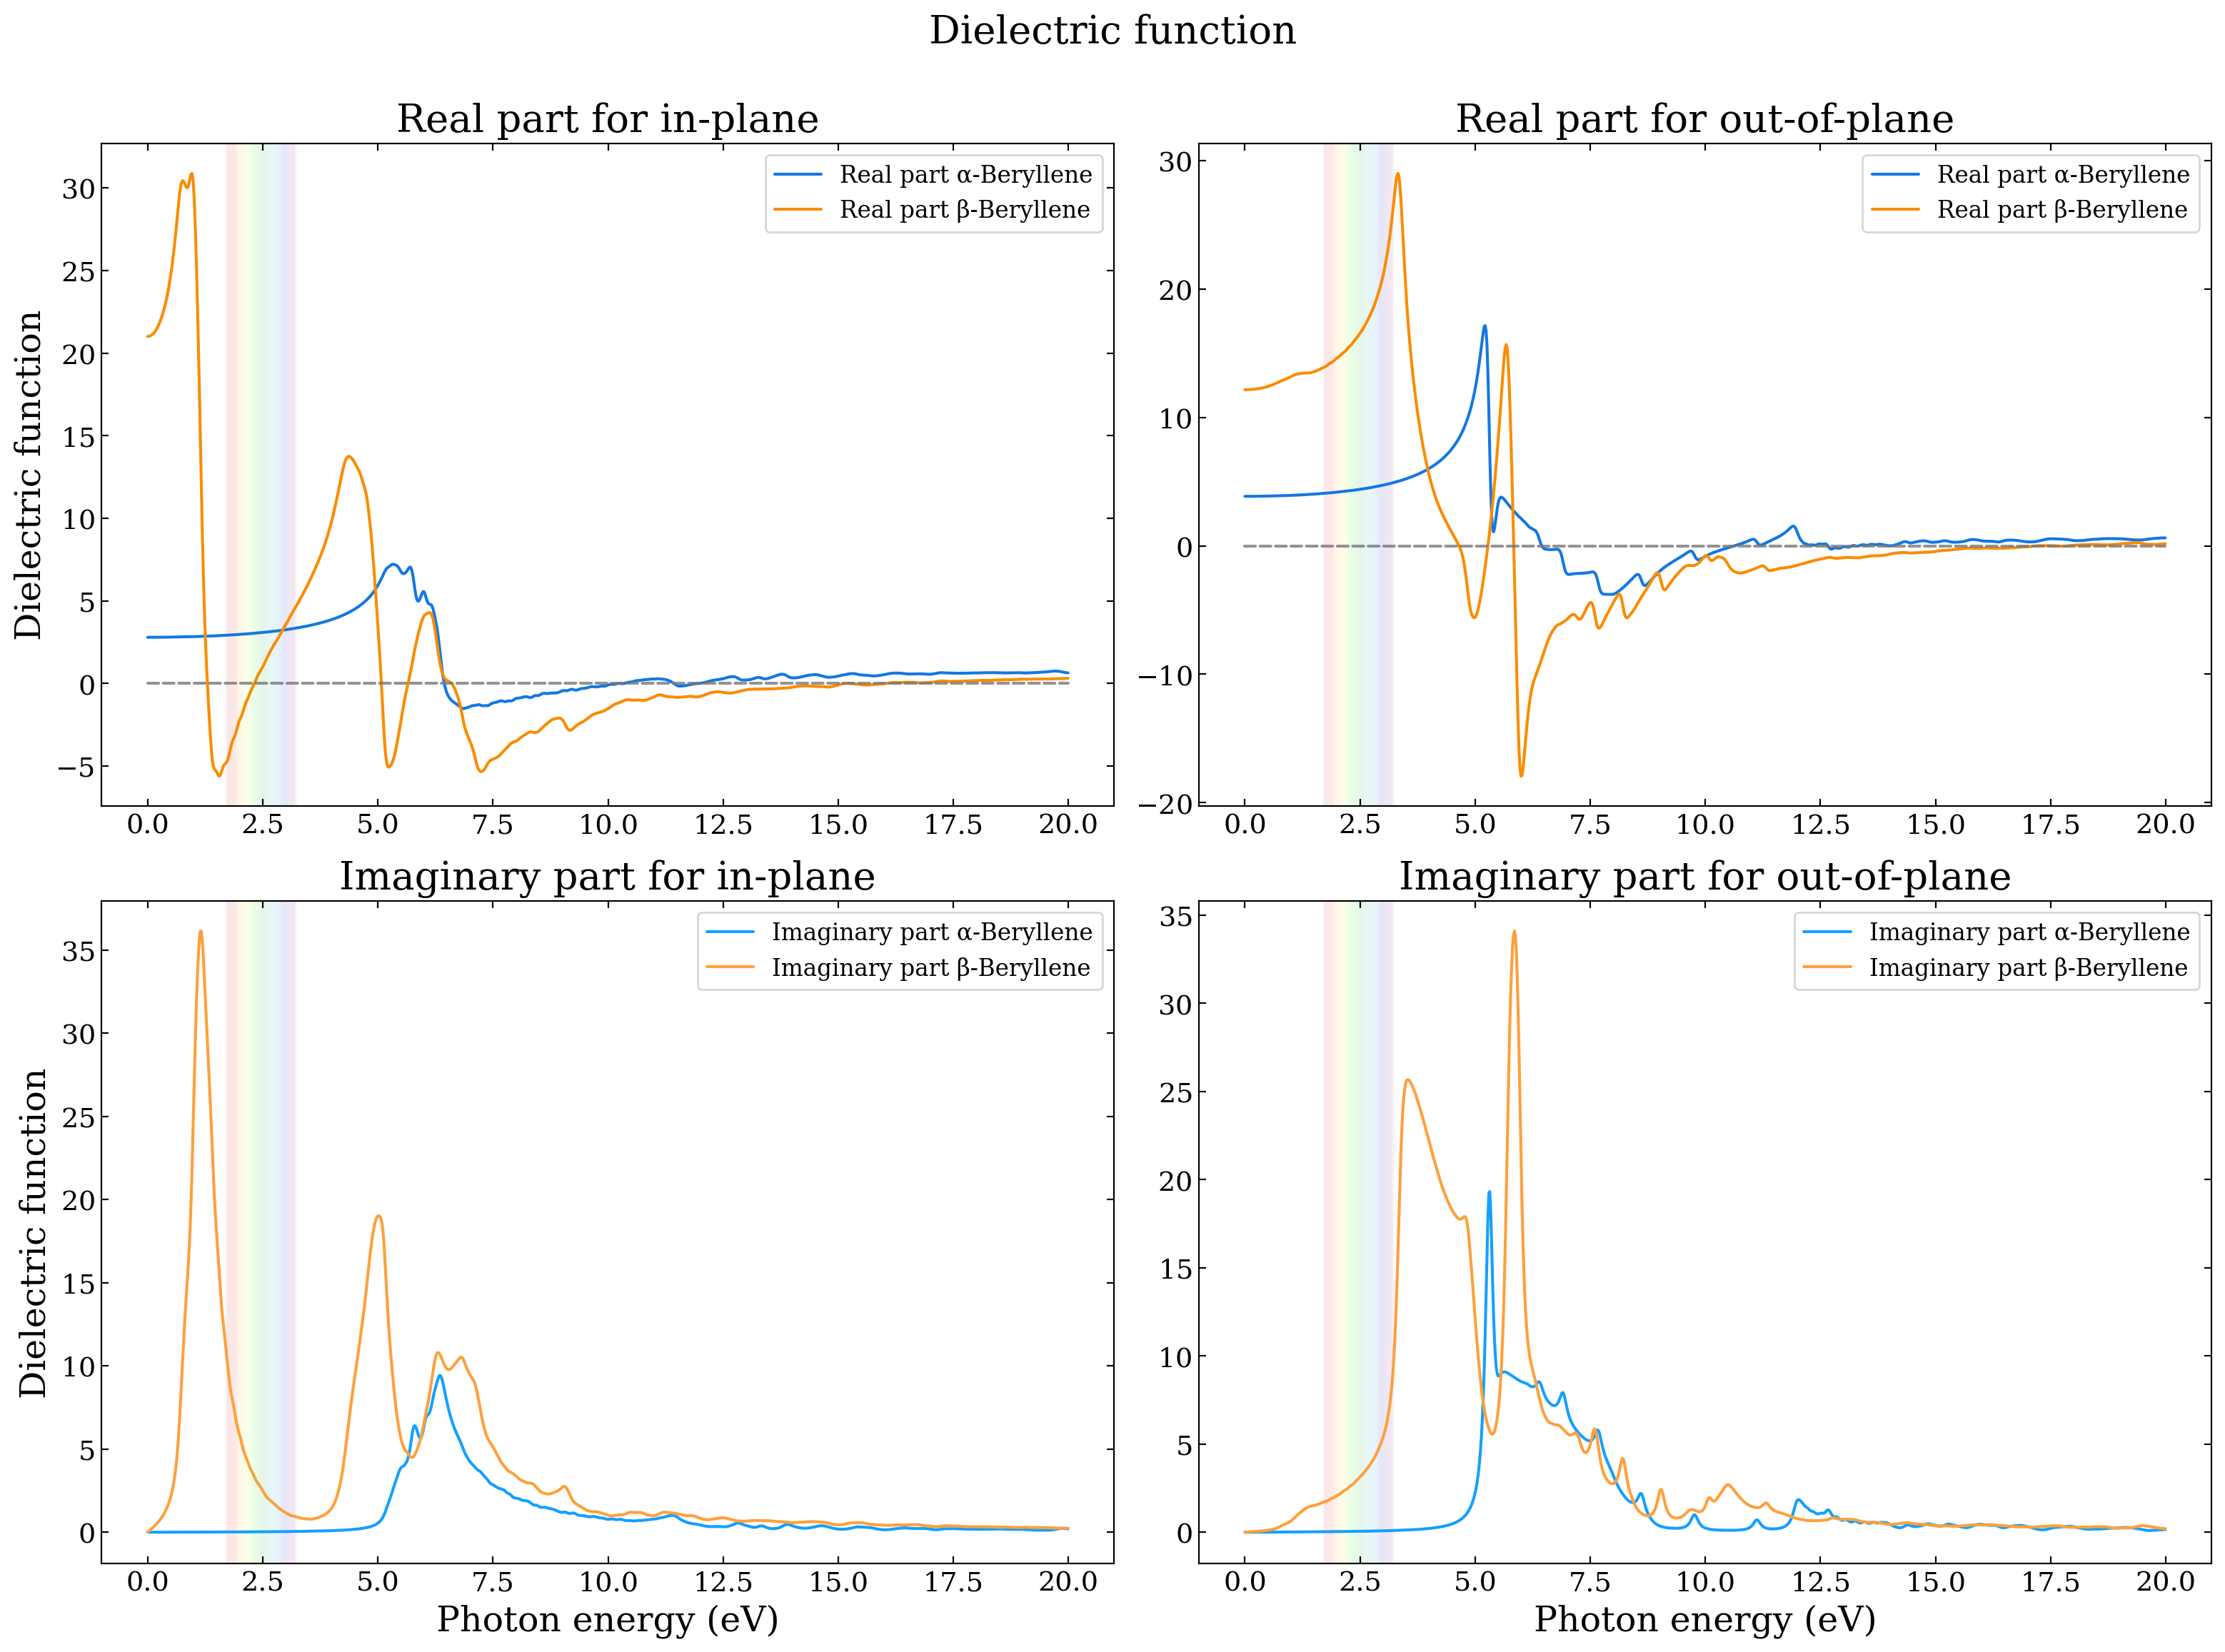

In [3]:
# Beryllene

import matplotlib.pyplot as plt
import vmatplot.dielectric_function as df

def my_canvas_setting(*args):
    size, dpi, params, titles, legend_loc = _canvas_setting(*args)
    params = dict(params)
    # params["font.family"] = besley_name
    # params["font.family"] = arbutus_name
    params["mathtext.fontset"] = "dejavuserif"
    return size, dpi, params, titles, legend_loc
df.canvas_setting = my_canvas_setting

systems = [["α-Beryllene",  "dielectric/a-Beryllene", "azure",  None,None,None, factor_a],
           ["β-Beryllene",  "dielectric/b-Beryllene", "orange", None,None,None, factor_b]]

components = [{"xx":"in-plane"},{"zz":"out-of-plane"}]
df.plot_dielectric_function("Dielectric function", systems, components, "hor", True, "eV", (0, 20), boundary, True)
fig = plt.gcf()

plt.savefig("figures/3.1_dielectric.pdf")


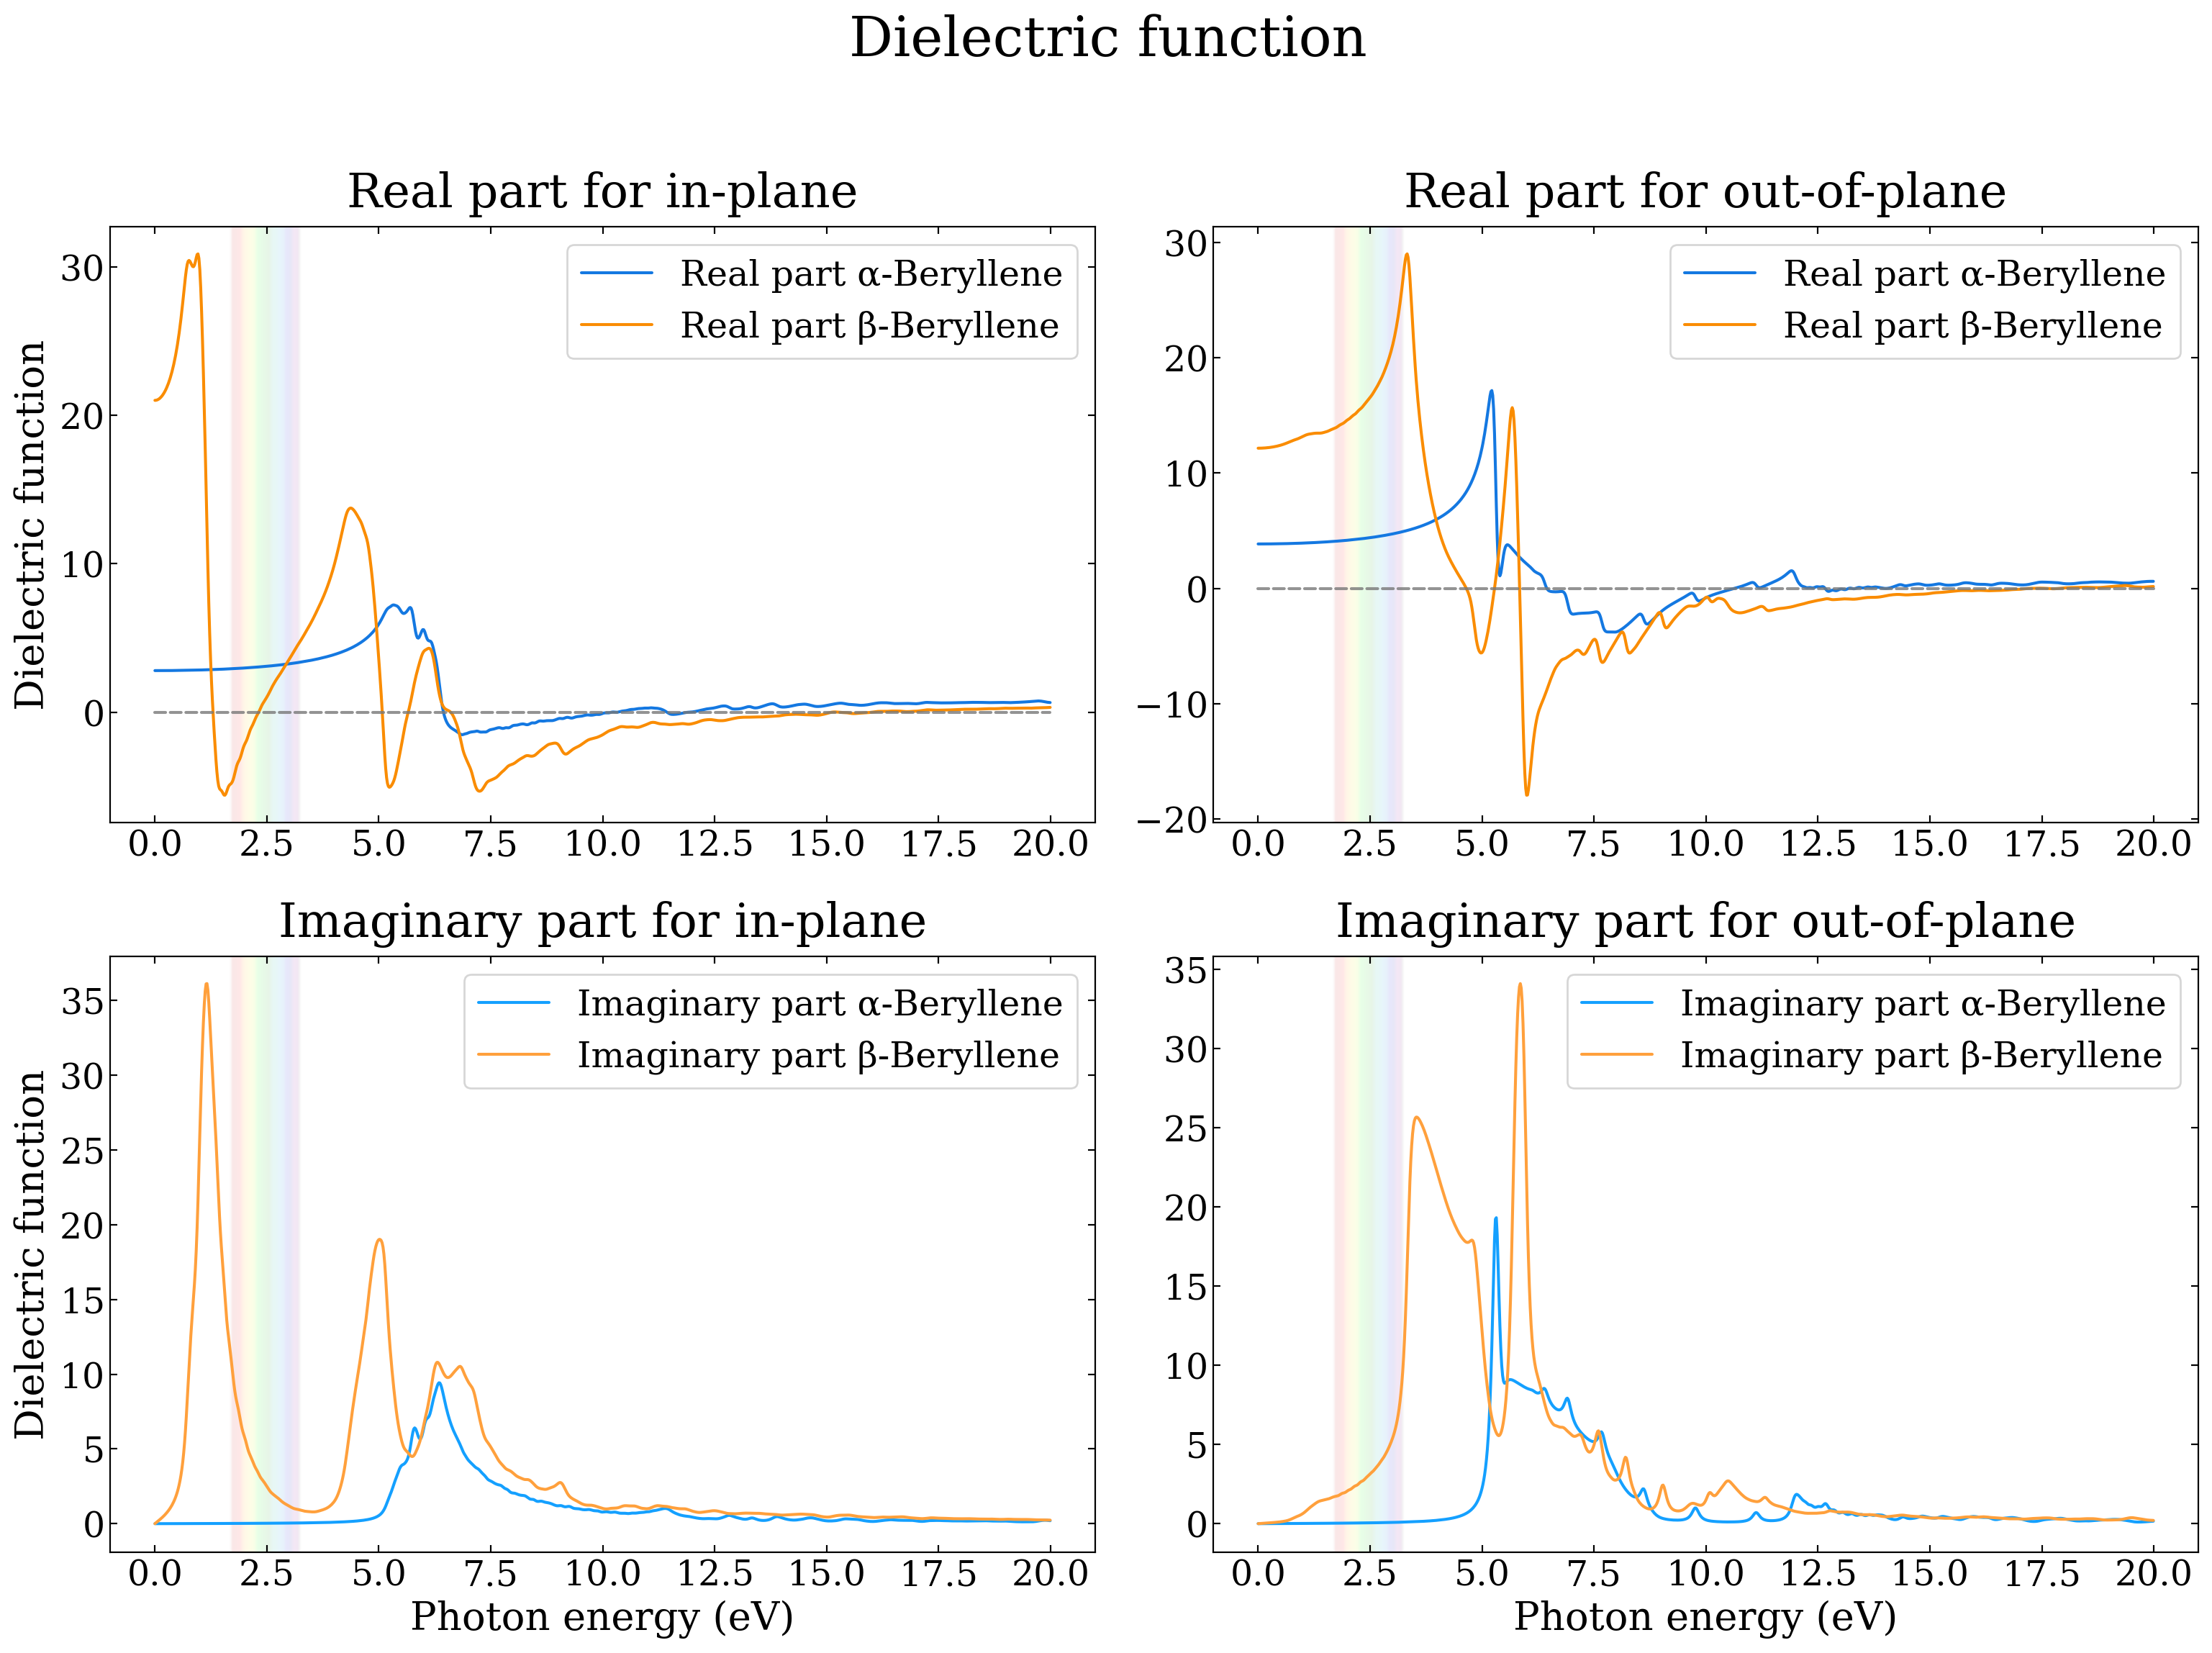

In [4]:
# Beryllene

import matplotlib.pyplot as plt
import vmatplot.dielectric_function as df

def my_canvas_setting(*args):
    size, dpi, params, titles, legend_loc = _canvas_setting(*args)
    params = dict(params)
    # params["font.family"] = besley_name
    # params["font.family"] = arbutus_name
    params["mathtext.fontset"] = "dejavuserif"
    params["axes.titlepad"] = 10
    params["font.size"] = 18
    params["axes.titlesize"] = 24
    params["axes.labelsize"] = 18
    params["xtick.labelsize"] = 18
    params["ytick.labelsize"] = 18
    params["legend.fontsize"] = 18
    titles = (28, 24) 
    return size, dpi, params, titles, legend_loc
df.canvas_setting = my_canvas_setting

systems = [["α-Beryllene",  "dielectric/a-Beryllene", "azure",  None,None,None, factor_a],
           ["β-Beryllene",  "dielectric/b-Beryllene", "orange", None,None,None, factor_b]]

components = [{"xx":"in-plane"},{"zz":"out-of-plane"}]
df.plot_dielectric_function("Dielectric function", systems, components, "hor", True, "eV", (0, 20), boundary, True)
fig = plt.gcf()
for ax in fig.axes:
    ax.xaxis.label.set_size(20)
    ax.yaxis.label.set_size(20)

plt.savefig("figures/3.1_dielectric_alt.pdf")
